### Load and Prepare Iris Dataset



In [ ]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
iris = load_iris()
X_iris_full = iris.data
y_iris_full = iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris_full, y_iris_full, test_size=0.3, random_state=42)

X_iris_binary = iris.data[:, :2]

binary_mask = (iris.target == 0) | (iris.target == 1)
X_iris_binary = X_iris_binary[binary_mask]
y_iris_binary = iris.target[binary_mask]

X_train_iris_binary, X_test_iris_binary, y_train_iris_binary, y_test_iris_binary = train_test_split(X_iris_binary, y_iris_binary, test_size=0.3, random_state=42)

In [ ]:
print("Iris datasets loaded and split successfully.")
print(f"X_train_iris shape: {X_train_iris.shape}")
print(f"X_test_iris shape: {X_test_iris.shape}")
print(f"y_train_iris shape: {y_train_iris.shape}")
print(f"y_test_iris shape: {y_test_iris.shape}")
print(f"X_train_iris_binary shape: {X_train_iris_binary.shape}")
print(f"X_test_iris_binary shape: {X_test_iris_binary.shape}")
print(f"y_train_iris_binary shape: {y_train_iris_binary.shape}")
print(f"y_test_iris_binary shape: {y_test_iris_binary.shape}")

Iris datasets loaded and split successfully.
X_train_iris shape: (105, 4)
X_test_iris shape: (45, 4)
y_train_iris shape: (105,)
y_test_iris shape: (45,)
X_train_iris_binary shape: (70, 2)
X_test_iris_binary shape: (30, 2)
y_train_iris_binary shape: (70,)
y_test_iris_binary shape: (30,)


### Train SVM with Linear Kernel



In [ ]:
svm_linear_iris = SVC(kernel='linear', random_state=42)
svm_linear_iris.fit(X_train_iris, y_train_iris)

print("Linear SVM model trained successfully on full Iris dataset.")

Linear SVM model trained successfully on full Iris dataset.


### Train SVM with Polynomial Kernel



In [ ]:
svm_poly_iris = SVC(kernel='poly', degree=3, random_state=42)
svm_poly_iris.fit(X_train_iris, y_train_iris)

print("Polynomial SVM model trained successfully on full Iris dataset.")

Polynomial SVM model trained successfully on full Iris dataset.


### Train SVM with RBF Kernel



In [ ]:
svm_rbf_iris = SVC(kernel='rbf', random_state=42)
svm_rbf_iris.fit(X_train_iris, y_train_iris)

print("RBF SVM model trained successfully on full Iris dataset.")

RBF SVM model trained successfully on full Iris dataset.


### Evaluate SVM Models

In [ ]:
y_pred_linear_iris = svm_linear_iris.predict(X_test_iris)
accuracy_linear_iris = accuracy_score(y_test_iris, y_pred_linear_iris)

y_pred_poly_iris = svm_poly_iris.predict(X_test_iris)
accuracy_poly_iris = accuracy_score(y_test_iris, y_pred_poly_iris)

y_pred_rbf_iris = svm_rbf_iris.predict(X_test_iris)
accuracy_rbf_iris = accuracy_score(y_test_iris, y_pred_rbf_iris)

print(f"Accuracy of Linear SVM on Iris dataset: {accuracy_linear_iris:.4f}")
print(f"Accuracy of Polynomial SVM on Iris dataset: {accuracy_poly_iris:.4f}")
print(f"Accuracy of RBF SVM on Iris dataset: {accuracy_rbf_iris:.4f}")

Accuracy of Linear SVM on Iris dataset: 1.0000
Accuracy of Polynomial SVM on Iris dataset: 0.9778
Accuracy of RBF SVM on Iris dataset: 1.0000


### Visualize Decision Boundaries

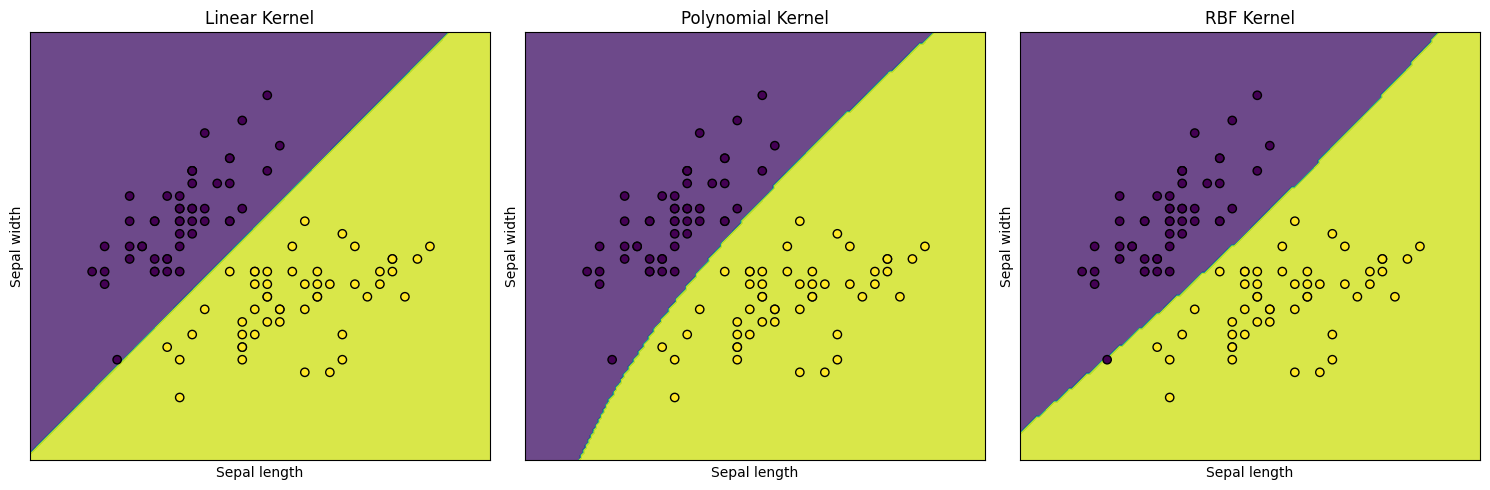

Decision boundaries visualized for linear, polynomial, and RBF SVM models on binary Iris dataset.


In [ ]:
# train a new linear SVM model on binary data
svm_linear_binary = SVC(kernel='linear', random_state=42)
svm_linear_binary.fit(X_train_iris_binary, y_train_iris_binary)

# train a new polynomial SVM model on binary data
svm_poly_binary = SVC(kernel='poly', degree=3, random_state=42)
svm_poly_binary.fit(X_train_iris_binary, y_train_iris_binary)

# train a new RBF SVM model on binary data
svm_rbf_binary = SVC(kernel='rbf', random_state=42)
svm_rbf_binary.fit(X_train_iris_binary, y_train_iris_binary)

# Create a list of these three newly trained binary SVM models and their corresponding titles
models = [
    (svm_linear_binary, 'Linear Kernel'),
    (svm_poly_binary, 'Polynomial Kernel'),
    (svm_rbf_binary, 'RBF Kernel')
]

# Define the minimum and maximum values for the x and y axes
x_min, x_max = X_iris_binary[:, 0].min() - 0.5, X_iris_binary[:, 0].max() + 0.5
y_min, y_max = X_iris_binary[:, 1].min() - 0.5, X_iris_binary[:, 1].max() + 0.5
h = .02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

plt.figure(figsize=(15, 5))

# For each model in the list
for i, (model, title) in enumerate(models):
    plt.subplot(1, len(models), i + 1)

    # Predict the class for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.8)
    plt.scatter(X_iris_binary[:, 0], X_iris_binary[:, 1], c=y_iris_binary, cmap=plt.cm.viridis, edgecolors='k')

    plt.title(title)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())

plt.tight_layout()
plt.show()

print("Decision boundaries visualized for linear, polynomial, and RBF SVM models on binary Iris dataset.")